# 04 - Exploratory Data Analysis
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Look at the data from every angle the objectives require - distributions, city comparison, time, month, year, season, weekday - and save each figure to visualizations/.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


In [2]:
import config as C
import data_utils as U
import preprocessing as P
import feature_engineering as FE
import figures as F
import viz as V
from IPython.display import display, Image

clean, *_ = P.clean(U.load_raw())
feat, _ = FE.build_features(clean)
polls = C.pollutant_columns(feat.columns)
V.style()
print("records:", f"{len(feat):,}", "| cities:", feat[C.CITY_COL].nunique(),
      "| pollutants analysed:", len(polls))

records: 18,265 | cities: 5 | pollutants analysed: 9


## 1. How AQI and the AQI categories are distributed

The mean/median pair and the category counts tell us where the data sits. No
axis is truncated and no 3-D effect is used.

,count,mean,std,min,25%,50%,75%,max
AQI,18265.0,317.51,113.89,26.9,207.1,331.6,414.0,500.0


,category,records,percent
0,Very Poor,5501,30.12
1,Severe,5258,28.79
2,Moderate,4258,23.31
3,Poor,3129,17.13
4,Satisfactory,113,0.62
5,Good,6,0.03


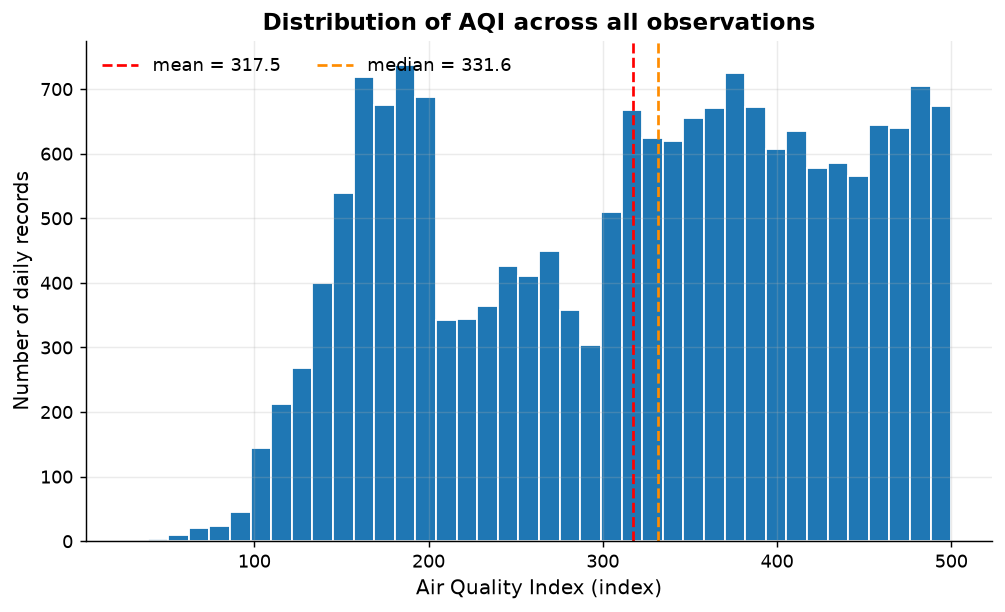

In [3]:
paths = F.eda(feat, polls)
display(feat[C.AQI_COL].describe().round(2).to_frame("AQI").T)
display(pd.DataFrame({"category": feat[C.TARGET_COL].astype(str).value_counts().index,
                      "records": feat[C.TARGET_COL].astype(str).value_counts().values,
                      "percent": (100 * feat[C.TARGET_COL].astype(str).value_counts()
                                  / len(feat)).round(2).values}))
Image(paths["01_aqi_distribution"])

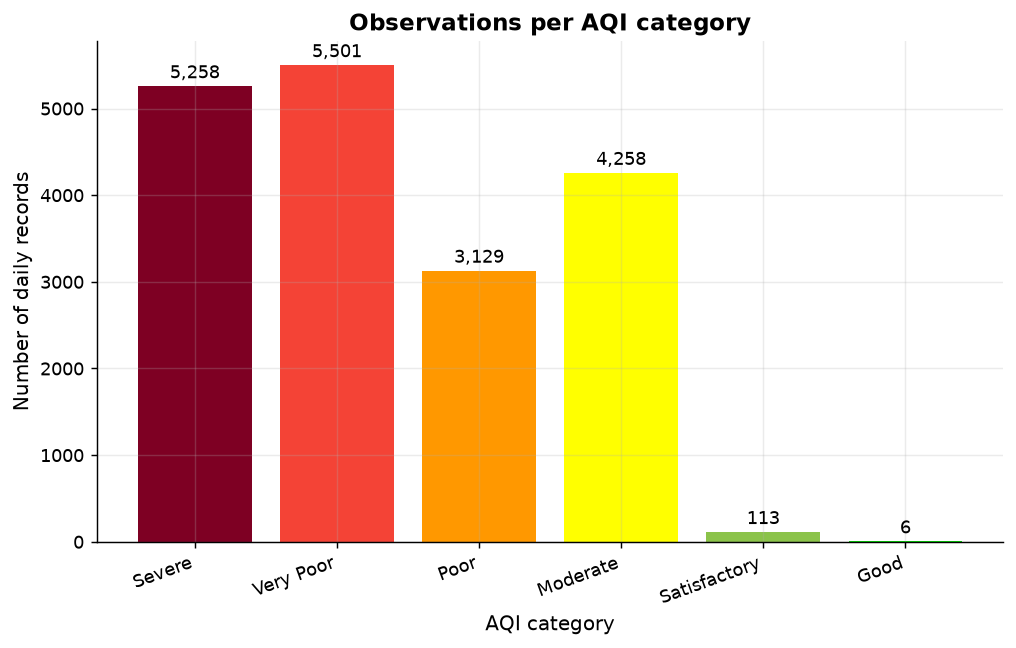

In [4]:
Image(paths["02_aqi_category_distribution"])

## 2. Cities

Average and median AQI per city, then the spread inside each city.

,count,mean,median,std,min,max
City,,,,,,
Mumbai,3653,318.18,332.5,113.13,37.7,500.0
Kolkata,3653,317.73,330.6,115.04,39.6,500.0
Delhi,3653,317.72,331.5,113.64,65.2,500.0
Bangalore,3653,317.27,332.0,113.77,26.9,500.0
Chennai,3653,316.62,331.4,113.93,44.7,500.0


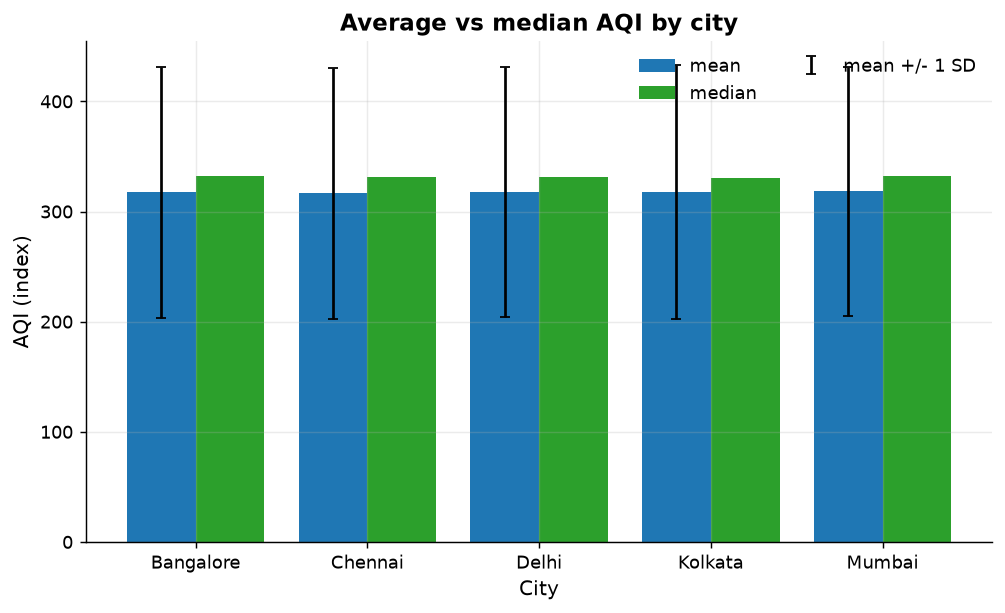

In [5]:
city = (feat.groupby(C.CITY_COL, observed=True)[C.AQI_COL]
            .agg(["count", "mean", "median", "std", "min", "max"]).round(2)
            .sort_values("mean", ascending=False))
display(city)
Image(paths["03_city_avg_median_aqi"])

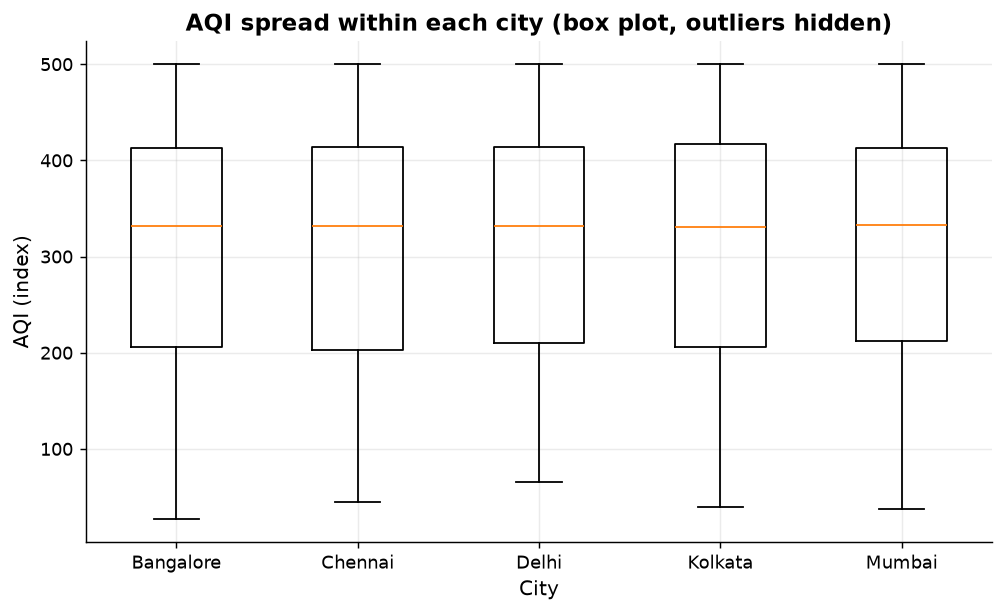

In [6]:
Image(paths["04_city_aqi_boxplot"])

### Is the difference between cities meaningful?

A visual gap between bars means nothing without a test, so the same comparison
is made formally here (and again in notebook 05).

In [7]:
import statistics_analysis as S
t = S.group_comparison(feat, C.AQI_COL, C.CITY_COL)
print(f"one-way ANOVA across the {len(t['group_means'])} cities: "
      f"F = {t['ANOVA_F']}, p = {t['ANOVA_p']}")
print(f"Kruskal-Wallis:                H = {t['Kruskal_H']}, p = {t['Kruskal_p']}")
print(f"spread between the highest and lowest city mean: "
      f"{t['Between_Group_Mean_Spread']} AQI points")
print()
print("Interpretation:",
      "the city means are statistically indistinguishable" if not t["Significant_at_0.05"]
      else "at least one city differs materially")

one-way ANOVA across the 5 cities: F = 0.0985, p = 0.983
Kruskal-Wallis:                H = 0.4201, p = 0.9808
spread between the highest and lowest city mean: 1.566 AQI points

Interpretation: the city means are statistically indistinguishable


## 3. Pollutant distributions

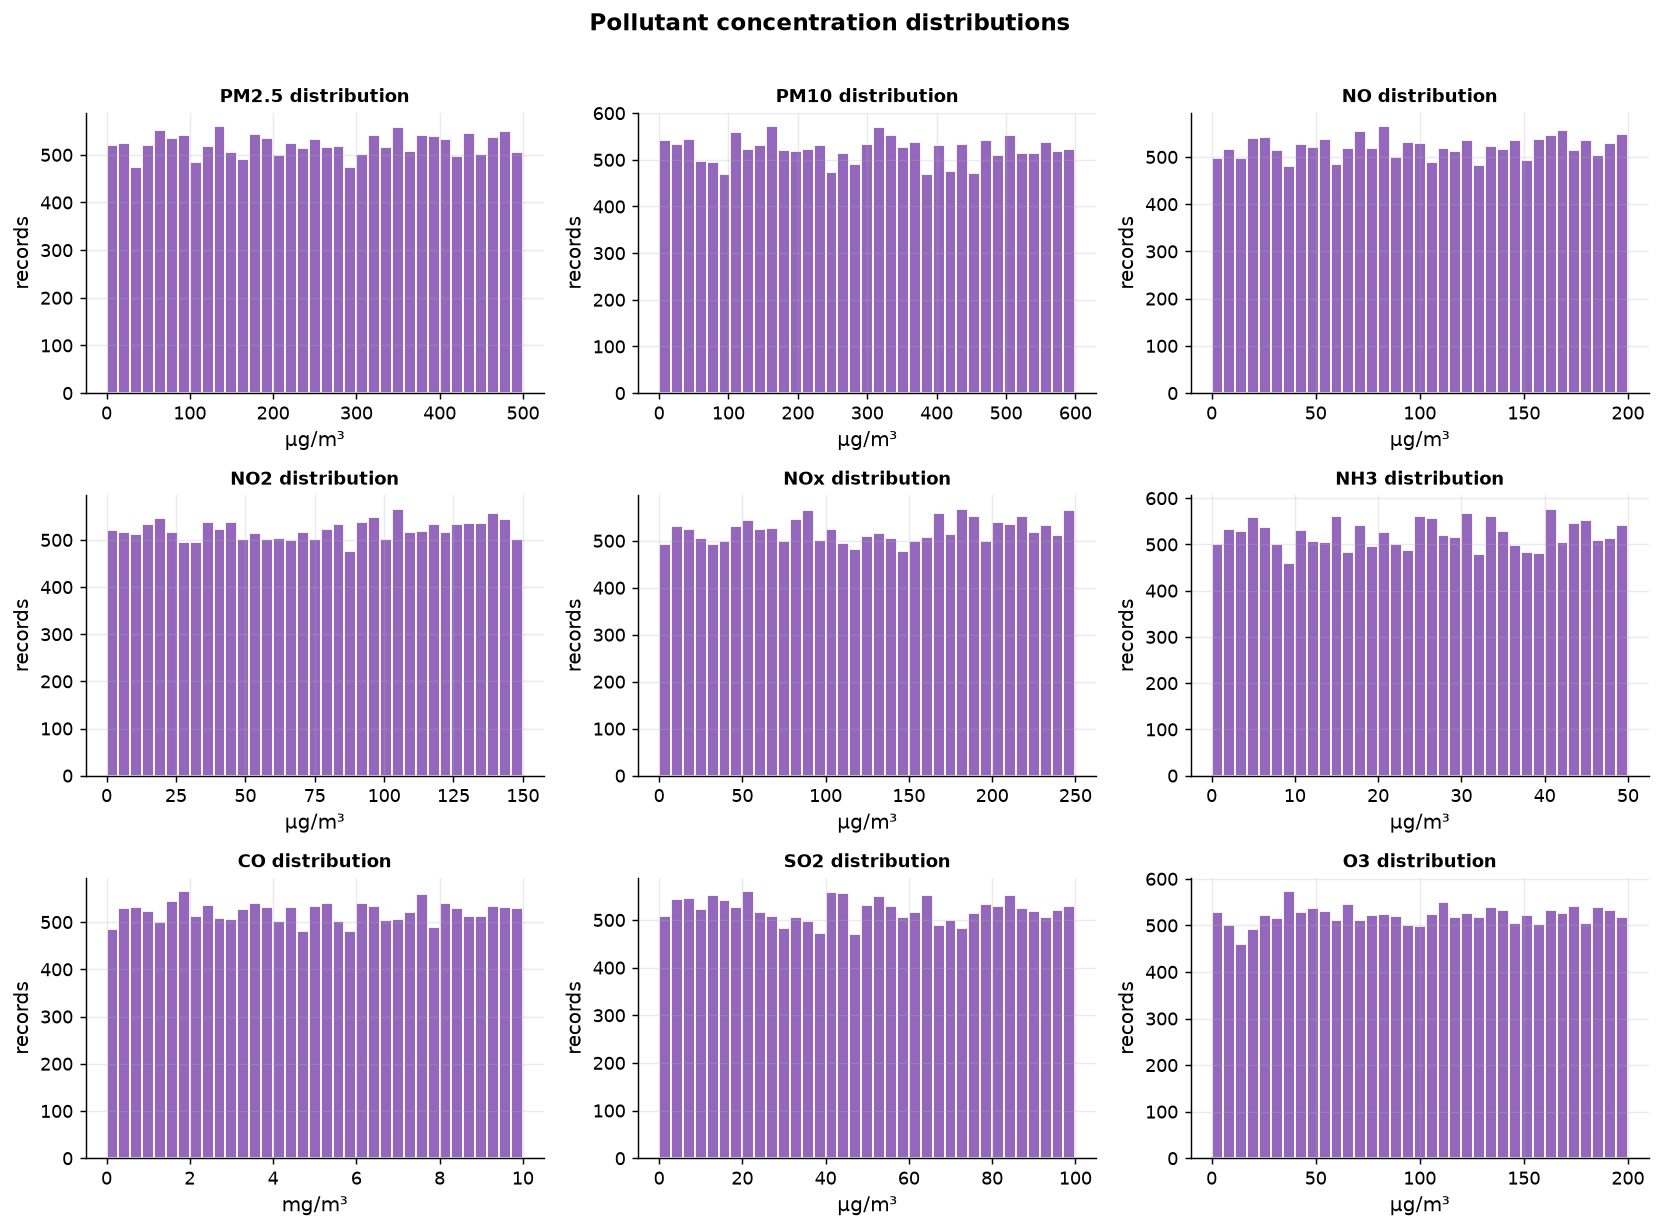

In [8]:
Image(paths["05_pollutant_distributions"])

In [9]:
display(S.descriptive_stats(feat, polls + [C.AQI_COL]))

,Variable,Count,Mean,Std,Min,Q1,Median,Q3,Max,IQR,Skewness,Kurtosis(excess),CV_%
0,PM2.5,18265,250.598,144.460,0.0,125.70,251.0,376.20,499.9,250.50,-0.005,-1.208,57.65
1,PM10,18265,299.442,173.480,0.0,150.10,300.3,450.00,600.0,299.90,0.005,-1.199,57.93
2,NO,18265,100.481,57.775,0.0,50.60,100.2,151.00,200.0,100.40,-0.005,-1.203,57.50
3,NO2,18265,75.416,43.460,0.0,37.70,76.0,113.20,150.0,75.50,-0.015,-1.213,57.63
4,NOx,18265,125.964,72.404,0.0,63.10,126.2,188.90,250.0,125.80,-0.012,-1.214,57.48
5,NH3,18265,25.065,14.452,0.0,12.60,25.3,37.60,50.0,25.00,-0.006,-1.200,57.66
6,CO,18265,5.002,2.889,0.0,2.49,5.0,7.51,10.0,5.02,0.004,-1.208,57.76
7,SO2,18265,49.836,28.989,0.0,24.40,49.9,75.10,100.0,50.70,0.005,-1.211,58.17
8,O3,18265,100.407,57.591,0.0,50.60,100.7,150.40,200.0,99.80,-0.002,-1.199,57.36
9,AQI,18265,317.505,113.895,26.9,207.10,331.6,414.00,500.0,206.90,-0.174,-1.194,35.87


## 4. Change over time

Daily AQI is noisy, so the trend chart aggregates to monthly means. A least-
squares line is drawn on the monthly series and its slope is reported.

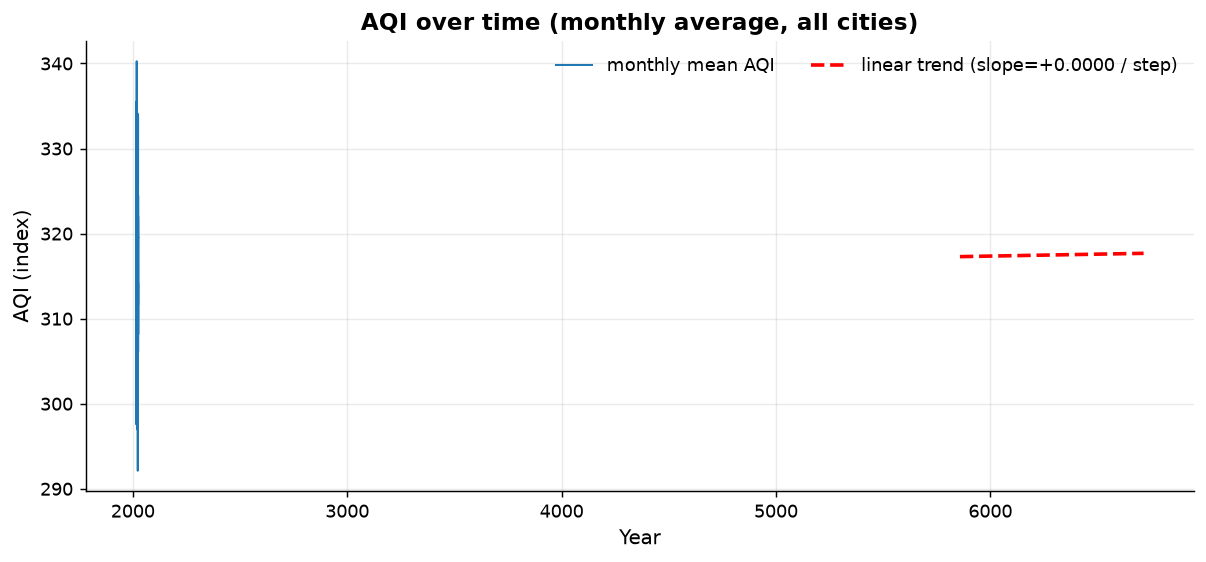

In [10]:
Image(paths["06_aqi_trend_time"])

In [11]:
trend = S.linear_trend_test(feat, C.AQI_COL)
print(f"fitted slope  : {trend['slope_per_year']} AQI points per year")
print(f"p-value       : {trend['p_value']}")
print(f"conclusion    : {trend['verdict']}")

fitted slope  : 0.0366 AQI points per year
p-value       : 0.9001
conclusion    : no statistically detectable trend


## 5. Month, year, season and weekday effects

,count,mean,median
Month,,,
1,1550,318.11,333.65
2,1415,315.03,333.10
3,1550,315.53,328.30
4,1500,319.57,332.10
5,1550,318.92,333.15
6,1500,314.84,325.45
7,1550,320.63,334.05
8,1550,316.80,333.35
9,1500,319.71,330.65


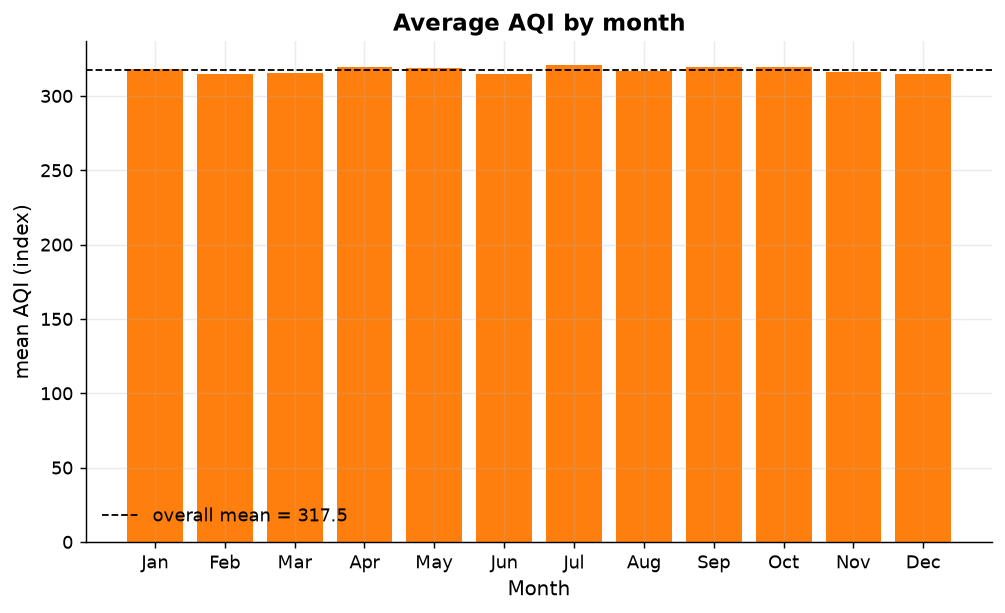

In [12]:
display(feat.groupby("Month", observed=True)[C.AQI_COL]
            .agg(["count", "mean", "median"]).round(2))
Image(paths["07_monthly_aqi"])

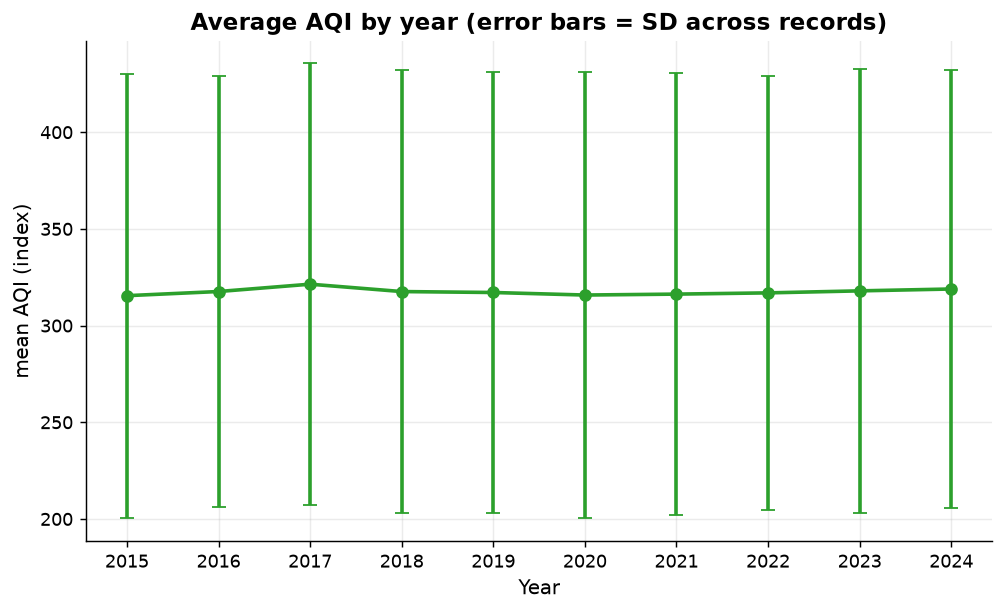

In [13]:
Image(paths["08_yearly_aqi"])

,count,mean,median,std
Season,,,,
Winter,4515,316.26,331.00,113.15
Summer,4550,317.79,331.05,114.20
Monsoon,4600,319.04,332.80,114.01
Post-Monsoon,4600,316.92,332.00,114.22


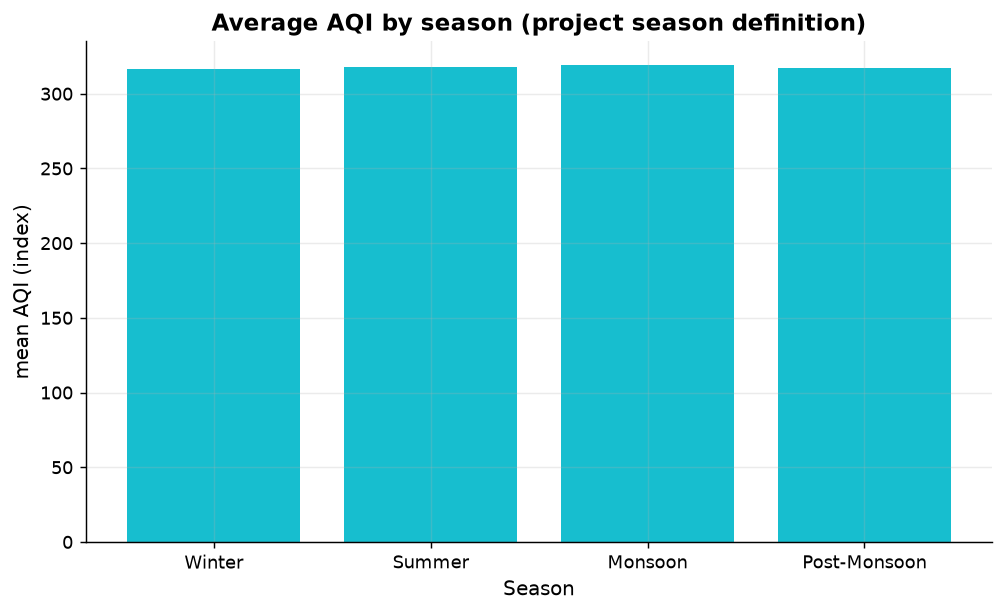

In [14]:
display(feat.groupby("Season", observed=True)[C.AQI_COL]
            .agg(["count", "mean", "median", "std"]).round(2))
Image(paths["09_seasonal_aqi"])

In [15]:
s = S.group_comparison(feat, C.AQI_COL, "Season")
w = S.group_comparison(feat, C.AQI_COL, "Is_Weekend")
print(f"season  : ANOVA p = {s['ANOVA_p']}, Kruskal p = {s['Kruskal_p']} -> "
      + ("significant" if s["Significant_at_0.05"] else "not significant"))
print(f"weekend : ANOVA p = {w['ANOVA_p']} -> "
      + ("significant" if w["Significant_at_0.05"] else "not significant"))

season  : ANOVA p = 0.6761, Kruskal p = 0.5963 -> not significant
weekend : ANOVA p = 0.1615 -> not significant


### The expected winter peak

Publicly reported Indian air quality is strongly seasonal, with a late-October to
January peak. The tests above find no seasonal effect in this file. That is
reported as a property of this dataset, not written around.

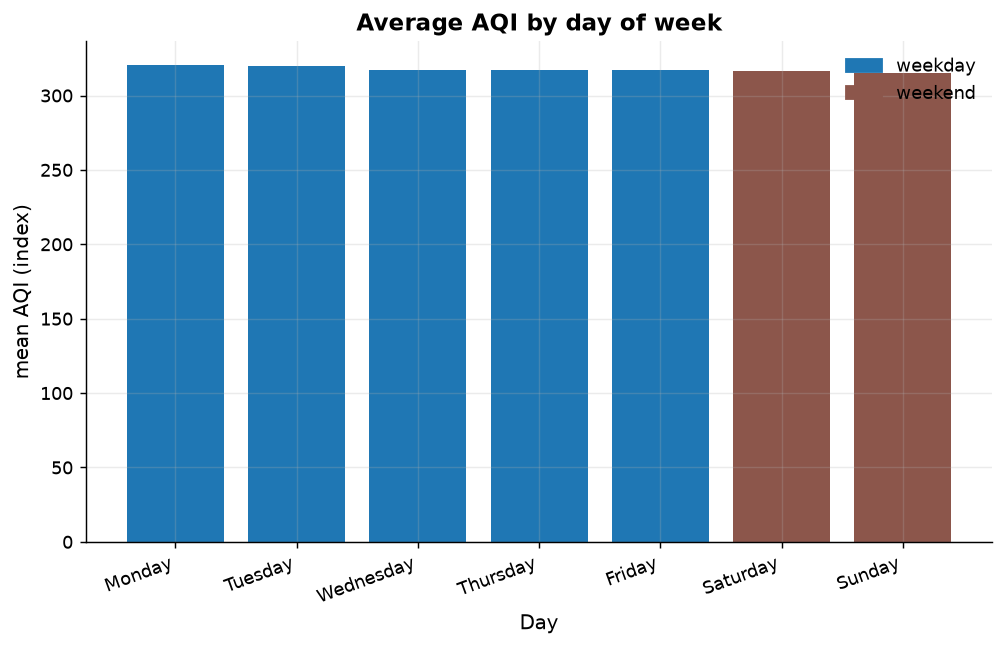

In [16]:
Image(paths["11_weekday_aqi"])

## 6. Particulate relationship and city x pollutant profile

In [17]:
Image(paths["10_pm25_vs_pm10"])
r = feat[["PM2.5", "PM10"]].corr().iloc[0, 1]
print(f"Pearson r between PM2.5 and PM10 in this dataset: {r:.4f}")

Pearson r between PM2.5 and PM10 in this dataset: -0.0248


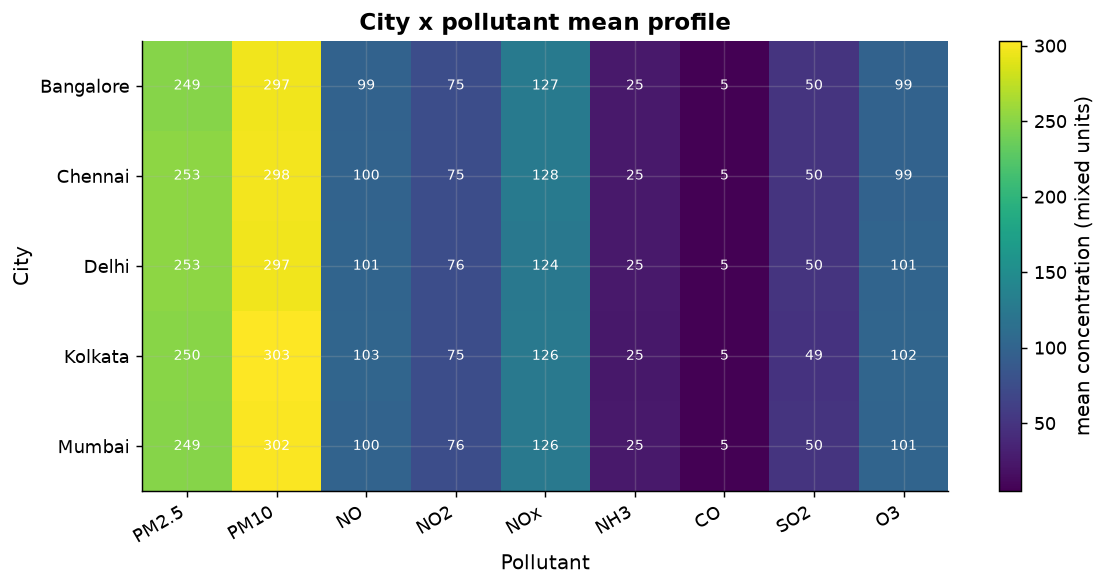

In [18]:
Image(paths["12_city_pollutant_heatmap"])

## 7. Figure index (saved for the report and README)

In [19]:
index = pd.DataFrame({"figure": list(paths.keys()), "path": list(paths.values())})
index["exists"] = [Path(p).exists() for p in paths.values()]
display(index)
index.to_csv(C.VIZ_DIR / "eda_figure_index.csv", index=False)
print("figures written under visualizations/eda/")

,figure,path,exists
0,01_aqi_distribution,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\01_aqi_distribution.png,True
1,02_aqi_category_distribution,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\02_aqi_category_distribu...,True
2,03_city_avg_median_aqi,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\03_city_avg_median_aqi.png,True
3,04_city_aqi_boxplot,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\04_city_aqi_boxplot.png,True
4,05_pollutant_distributions,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\05_pollutant_distributio...,True
5,06_aqi_trend_time,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\06_aqi_trend_time.png,True
6,07_monthly_aqi,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\07_monthly_aqi.png,True
7,08_yearly_aqi,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\08_yearly_aqi.png,True
8,09_seasonal_aqi,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\09_seasonal_aqi.png,True
9,10_pm25_vs_pm10,C:\Users\DELL\OneDrive\Desktop\Air Quality\visualizations\eda\10_pm25_vs_pm10.png,True


figures written under visualizations/eda/


## Verification checklist

- [x] All 16 required EDA views generated
- [x] Every figure titled, labelled and saved with units
- [x] Visual differences between cities backed by a statistical test
- [x] Absence of seasonality reported rather than assumed

**Common errors**

| Error | Meaning | Fix |
|---|---|---|
| `KeyError: 'Day_Name'` | feature engineering not run first | run the second cell of this notebook |
| Empty PNG files | previous run crashed before drawing | re-run from the bootstrap cell |

**Next:** `05_correlation_analysis.ipynb`.